### Dados de 2022

#### 3-10kev

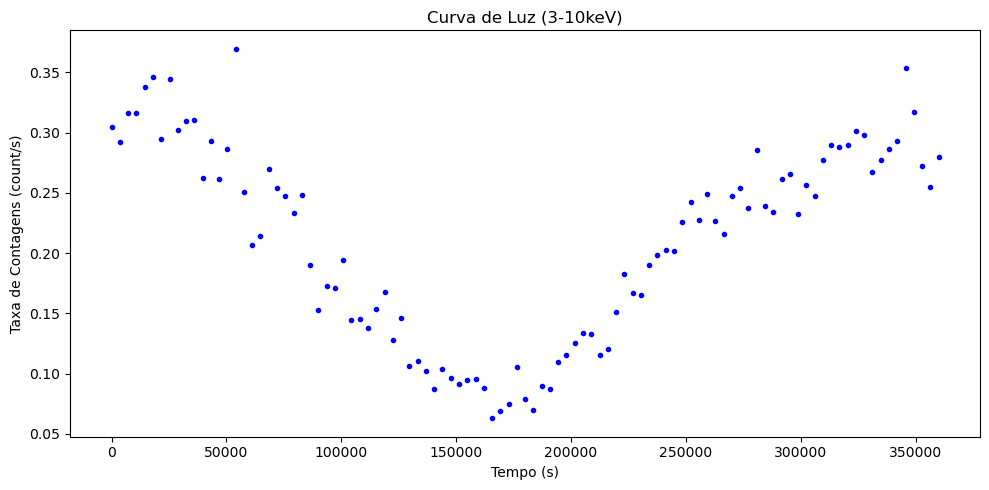

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/3-10kev/nu30701024002A01_sr.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10keV)')


plt.tight_layout()
plt.show()

In [6]:
from astropy.io import fits

hdr = fits.getheader('data/Dados 2022/3-10kev/nu30701024002A01_sr.lc', hdu=1)

chaves = [
    'OBJECT',
    'TELESCOP',
    'INSTRUME',
    'OBS_ID',
    'DATE-OBS',
    'DATE-END',
    'MJDREFI',
    'MJDREFF',
    'TSTART',
    'TSTOP',
    'ONTIME',
]

for chave in chaves:
    if chave in hdr:
        print(f'{chave:10s} = {hdr[chave]} \t/ {hdr.comments[chave]}')

OBJECT     = LS_5039 	/ Name of observed object
TELESCOP   = NuSTAR 	/ Telescope (mission) name
INSTRUME   = FPMA 	/ Instrument name
OBS_ID     = 30701024002 	/ Observation ID
DATE-OBS   = 2022-04-09T22:48:12.6041 	/ Start date of observations
DATE-END   = 2022-04-14T03:29:03.0345 	/ End date of observations
MJDREFI    = 55197 	/ MJD reference day
MJDREFF    = 0.00076601852 	/ MJD reference (fraction of day)
TSTART     = 387240426.4200499 	/ time start
TSTOP      = 387602876.8504873 	/ time stop
ONTIME     = 194468.0829269886 	/ On-source time


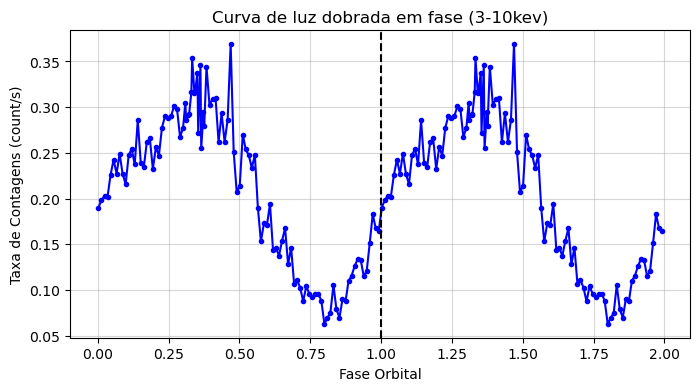

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

caminho = 'data/Dados 2022/3-10kev/nu30701024002A01_sr.lc'

tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase (3-10kev)')
plt.grid(True, alpha=0.5)
plt.show()

### 10-30kev

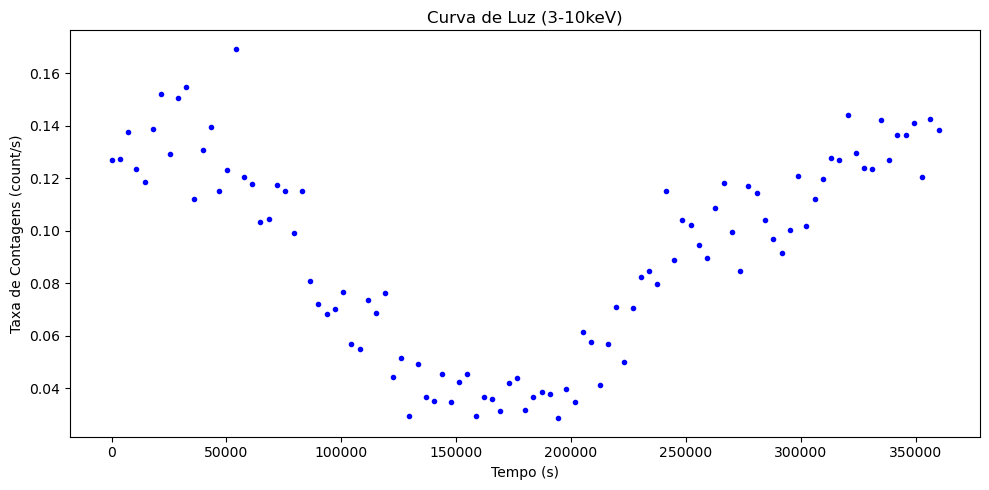

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/10-30kev/nu30701024002A01_sr.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10keV)')


plt.tight_layout()
plt.show()

### 30-70kev

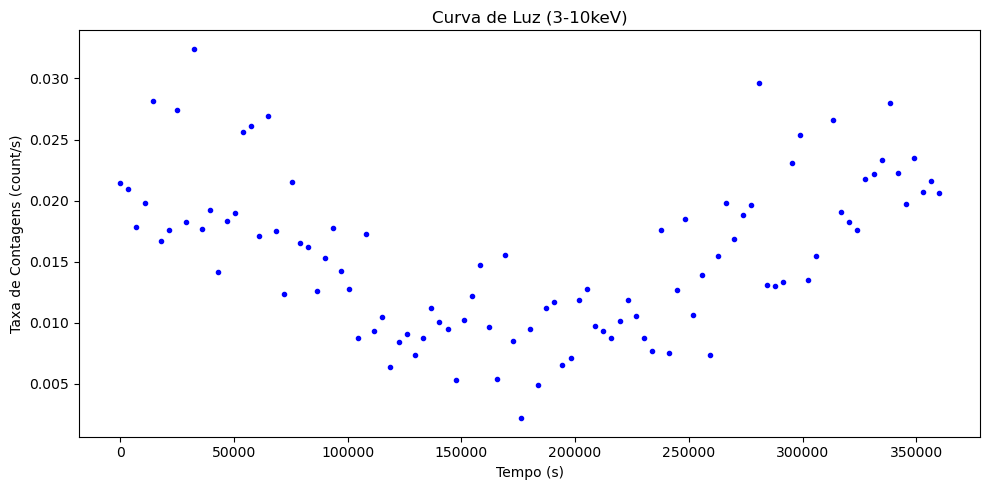

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('data/Dados 2022/30-70kev/nu30701024002A01_sr.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10keV)')


plt.tight_layout()
plt.show()